In [20]:
from matplotlib import pyplot as plt
# from brokenaxes import brokenaxes
import numpy as np
import os
import sys
# import seaborn as sns
import matplotlib.ticker as mticker
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as mtick

my_figsize = [10, 8]
my_fontsize = 35
WIDTH = 0.05  # the width of the bars
SHORT = 100000 # 100KB
LONG = 1000000 # 1000KB
LOADS = ['0.1', '0.25', '0.5', '0.75', '1']
labels = ['10', '25', '50', '75', '100']

WORKLOADS = ['W5']

METRICS = ['FCT', 'GOODPUT']

os.chdir(sys.path[0])
os.chdir('./')
# sns.set_theme(font='SimHei')
SCHEMES = [
        "../../DATA/PS-Slot-length/length=5",
        "../../DATA/PS-Slot-length/length=11",
        "../../DATA/PS-Slot-length/length=22",
        "../../DATA/PS-Slot-length/length=45",
        # "../../../DCTCP/DATA/thesis/W5_125_all_28",
        ]
SCHEMES_label = [
                r"Len=0.5$\mu$s",
                r"Len=1$\mu$s",
                r"Len=2$\mu$s",
                r"Len=4$\mu$s",
                #  "DCTCP"
                 ]
# Flashpod/ESN/DATA/NSDI25/multipods/W5_28_correct_ECMP

DATA_DIR_TEMP = '{scheme}/DATA_'+ WORKLOADS[0]+ '_{load}/'

# FIG_FILE_NAME = WORKLOADS[0]
# FIGURE_DIR = '../FIGS/'+ FIG_FILE_NAME +'/GOODPUT/'
# if not os.path.exists(FIGURE_DIR):
#     os.makedirs(FIGURE_DIR)

data = {}
for scheme in SCHEMES:
    data[scheme] = {}
    for workload in WORKLOADS:
        data[scheme][workload] = {}
        for load in LOADS:
            data[scheme][workload][load] = {}
   
for scheme in SCHEMES:
        for workload in WORKLOADS:
            for load in LOADS:
                dir_path = DATA_DIR_TEMP.format(scheme=scheme, workload=workload, load=load)
                data[scheme][workload][load]['PATH'] = dir_path
                for metric in METRICS:
                    data_path = dir_path + metric + '.txt'
                    data[scheme][workload][load][metric] = np.loadtxt(data_path)
                    print("LOADED: ", scheme, workload, load, metric)

for scheme in SCHEMES:
        for workload in WORKLOADS:
            for load in LOADS:
                    data[scheme][workload][load]['SHORT_IDX'] = data[scheme][workload][load]['FCT'][:, 4] < SHORT
                    data[scheme][workload][load]['LONG_IDX'] = data[scheme][workload][load]['FCT'][:, 4] > LONG
                    data[scheme][workload][load]['MIDDLE_IDX'] = (data[scheme][workload][load]['FCT'][:, 4] >= SHORT) * (data[scheme][workload][load]['FCT'][:, 4] <= LONG)

LOADED:  ../../DATA/PS-Slot-length/length=5 W5 0.1 FCT
LOADED:  ../../DATA/PS-Slot-length/length=5 W5 0.1 GOODPUT
LOADED:  ../../DATA/PS-Slot-length/length=5 W5 0.25 FCT
LOADED:  ../../DATA/PS-Slot-length/length=5 W5 0.25 GOODPUT
LOADED:  ../../DATA/PS-Slot-length/length=5 W5 0.5 FCT
LOADED:  ../../DATA/PS-Slot-length/length=5 W5 0.5 GOODPUT
LOADED:  ../../DATA/PS-Slot-length/length=5 W5 0.75 FCT
LOADED:  ../../DATA/PS-Slot-length/length=5 W5 0.75 GOODPUT
LOADED:  ../../DATA/PS-Slot-length/length=5 W5 1 FCT
LOADED:  ../../DATA/PS-Slot-length/length=5 W5 1 GOODPUT
LOADED:  ../../DATA/PS-Slot-length/length=11 W5 0.1 FCT
LOADED:  ../../DATA/PS-Slot-length/length=11 W5 0.1 GOODPUT
LOADED:  ../../DATA/PS-Slot-length/length=11 W5 0.25 FCT
LOADED:  ../../DATA/PS-Slot-length/length=11 W5 0.25 GOODPUT
LOADED:  ../../DATA/PS-Slot-length/length=11 W5 0.5 FCT
LOADED:  ../../DATA/PS-Slot-length/length=11 W5 0.5 GOODPUT
LOADED:  ../../DATA/PS-Slot-length/length=11 W5 0.75 FCT
LOADED:  ../../DATA/PS-

In [21]:
def goodput_bar_plot(labels, ax=0):
    # _, ax = plt.subplots(figsize=my_figsize)
    results = {}
    i = 0
    for ii, scheme in enumerate(SCHEMES):
        results[scheme] = []
        i = i + 100
        for load in LOADS:
            idx = data[scheme][workload][load]['GOODPUT'][:, 2] > 0
            goodput = data[scheme][workload][load]['GOODPUT'][idx, 1] # goodput
            if ii < 5:
                results[scheme].append(np.mean(goodput))
            else:
                results[scheme].append(np.mean(goodput))


    x_tick = np.arange(len(labels))*0.3 # the label locations
    x = x_tick - (len(SCHEMES)-1)*WIDTH/2

    # plt.subplots_adjust(left=0.15, right=0.99, bottom=0.2, top=0.9)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['top'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)
    ax.spines['right'].set_linewidth(2.0)
    

    
    for i, scheme in enumerate(SCHEMES):
        bound = len(SCHEMES_label) / 2
        bound = 4
        # if i == len(SCHEMES_label) - 1:
        #     ax.bar(x + WIDTH*i, results[scheme], WIDTH, edgecolor='darkblue', color=[colors[i]], label=SCHEMES_label[i], hatch='\\', linewidth = 3)
        #     continue

        ax.bar(x + WIDTH*i, results[scheme], WIDTH, color=[colors[i]], label=SCHEMES_label[i], hatch=hatches[i], linewidth = 3)
        # ax.bar(x + WIDTH*(i), results[scheme], WIDTH, edgecolor="firebrick", color=[colors[i]], label=SCHEMES_label[i], hatch=hatches[i], linewidth = 3)
    # print(results)
    # ax.set_title('Accelerate by adding line rate', fontsize=my_fontsize)
    # ax.set_ylabel('Goodput\n(normalized)', fontsize=my_fontsize)
    ax.set_ylabel('吞吐 (Gbps)', fontsize=my_fontsize-5)
    ax.set_xticks(x_tick)
    # ax.set_yticks([0, 20, 40, 60, 80])
    # ax.set_xlabel("Incast Degree", fontsize=my_fontsize)
    ax.set_xlabel("负载 (%)", fontsize=my_fontsize-5)
    ax.set_xticklabels(labels, fontsize=my_fontsize)
    # ax.legend(ncol=1, loc = "upper left", fontsize=my_fontsize-25, framealpha=0)
    

    plt.xticks(fontsize=my_fontsize-5)
    ax.tick_params(axis='both', which='both', length=5, labelsize=my_fontsize)

    ax.grid(axis="y")

    # plt.yticks(fontsize=my_fontsize-5)
    # ax.tick_params(which='major',  # 设置刻度线的类型为主刻度线和次刻度线
    #            top=False,     # 不显示顶部刻度线
    #            left=False,    # 不显示左边刻度线
    #            right=False,   # 不显示右边刻度线
    #            bottom=False)

In [22]:
def slowdown_bar_plot(mode, labels, workload, ax, flow_range='all', unit='us'):
    # _, ax = plt.subplots(figsize=my_figsize)
    results = {}
    for i, scheme in enumerate(SCHEMES):
        results[scheme] = []
        for load in LOADS:

            if flow_range == 'Mice':
                idx = data[scheme][workload][load]['SHORT_IDX']
            elif flow_range == 'Elephant':
                idx = data[scheme][workload][load]['LONG_IDX']
            elif flow_range == 'middle':
                idx = data[scheme][workload][load]['MIDDLE_IDX']
            elif flow_range == 'all':
                idx = np.arange(len(data[scheme][workload][load]['FCT']))

            available_idx = data[scheme][workload][load]['FCT'][:, 7] > 0 # 过滤未完成的流
            idx = idx * available_idx

            # max_start_time = max(data[scheme][workload][load]['FCT'][:, 1])
            # truncated_time = 1.0 + (max_start_time-1) * (float(load))

            # available_idx = data[scheme][workload][load]['FCT'][:, 1] < truncated_time # 筛选出start time 在前load%的流，按照固定时间取流
            # idx = idx * available_idx
            # available_idx = data[scheme][workload][load]['FCT'][:, 0] <= 99999 # 
            # idx = idx * available_idx
            # if i == 0 and load=='0.1':
            #     # print(data[scheme][workload][load]['FCT'][idx, :])
            #     np.savetxt('truncated.txt', data[scheme][workload][load]['FCT'][idx, :], fmt='%.08f')

            fct = data[scheme][workload][load]['FCT'][idx, 7] # fct
            # fct = fct[:1000]
            
            # print("\n\n\n")
            # print(fct)
            # print(max(fct))
            # print(np.argmax(fct))
            # print(scheme, workload, load, ": ")
            # print(max(fct))
            # print(np.argmax(fct))
            # print(data[scheme][workload][load]['FCT'][np.argmax(fct), :])
            
            # print(max(fct))

            # print(scheme, ', load =', load, ', flow num =', str(len(fct)), ', truncated time =', truncated_time)

            if mode == 'Mean':
                results[scheme].append(np.mean(fct) * 1e3)
            elif mode == 'Median':
                results[scheme].append(np.percentile(fct, 50) * 1e3)
            elif mode == '80p':
                results[scheme].append(np.percentile(fct, 80) * 1e3)
            elif mode == '90p':
                results[scheme].append(np.percentile(fct, 90) * 1e3)
            elif mode == '95p':
                results[scheme].append(np.percentile(fct, 95) * 1e3)
            elif mode == '99p':
                if unit == 'us':
                    results[scheme].append(np.percentile(fct, 99) * 1e6)
                else:
                    results[scheme].append(np.percentile(fct, 99) * 1e3)
            elif mode == '99.9p':
                if unit == 'us':
                    results[scheme].append(np.percentile(fct, 99.9) * 1e6)
                else:
                    results[scheme].append(np.percentile(fct, 99.9) * 1e3)
                



    print(results)


    x_tick = np.arange(len(labels))*0.3 # the label locations
    x = x_tick - (len(SCHEMES)-1)*WIDTH/2

    # fig, ax = plt.subplots(figsize=my_figsize)
    # plt.subplots_adjust(left=0.16, right=0.99, bottom=0.2, top=0.9)

    ax.spines['bottom'].set_linewidth(2.0)
    ax.spines['top'].set_linewidth(2.0)
    ax.spines['left'].set_linewidth(2.0)
    ax.spines['right'].set_linewidth(2.0)
    
    ax.grid(axis='y')
    
    for i, scheme in enumerate(SCHEMES):
        # ax.bar(x + WIDTH*i, results[scheme][mode], WIDTH, label=scheme)
        # 一次画一个scheme的所有load的bar
        # if i == len(SCHEMES_label) - 1:
        #     ax.bar(x + WIDTH*i, results[scheme], WIDTH, edgecolor='darkblue', color=[colors[i]], label=SCHEMES_label[i], hatch='\\', linewidth = 3)
        #     continue
        bound = len(SCHEMES_label) / 2

        ax.bar(x + WIDTH*i, results[scheme], WIDTH, label=SCHEMES_label[i], linewidth = 3, color=[colors[i]], hatch=hatches[i])
        # ax.bar(x + WIDTH*i, results[scheme][pias], WIDTH, edgecolor="firebrick", label=SCHEMES_label[i], linewidth = 3, color=[colors[i]], hatch=hatches[i])
        
    if mode == "Mean":
        ax.set_xlabel("Load (%)", fontsize=my_fontsize-5)
        if flow_range == "Elephant":
            ax.set_ylabel('Avg. FCT of long flows (ms)', fontsize=my_fontsize-5)
        else:
            ax.set_ylabel('Avg. FCT of ' + flow_range + " flows (ms)", fontsize=my_fontsize-5)
        # ax.set_ylabel('Avg. FCT (ms)', fontsize=my_fontsize)
    elif mode == '90p':
        ax.set_ylabel('90-p. FCT of short flows (ms)', fontsize=my_fontsize-5)
    elif mode == "99p":
        if unit == 'us':
            ax.set_ylabel(r'99百分位流完成时间 ($\mu$s)', fontsize=my_fontsize-5)
        else:
            ax.set_ylabel('99p. FCT (ms)', fontsize=my_fontsize-5)
        
    elif mode == "99.9p":
        ax.set_ylabel(r'99.9-p. FCT ($\mu$s)', fontsize=my_fontsize-5)
    else:
        ax.set_ylabel('FCT of ' + flow_range + " flows (ms)", fontsize=my_fontsize)

    ax.set_xlabel("负载 (%)", fontsize=my_fontsize-5)
    ax.set_xticks(x_tick)
    # ax.set_yscale('log')


    plt.xticks(fontsize=my_fontsize-5)
    # plt.yticks([0, 30, 60, 90], fontsize=my_fontsize-5)


    ax.set_xticklabels(labels, fontsize=my_fontsize-5)
    
    ax.tick_params(axis='both', which='both', length=5, labelsize=my_fontsize)
    ax.grid(axis='both', which='minor', linewidth=0.5, alpha=0.5)
    # ax.legend(ncol=1, loc = "upper left", fontsize=40, framealpha=0)
    # plt.savefig(figure_path, dpi=300, bbox_inches='tight')

### 主实验

{'../../DATA/PS-Slot-length/length=5': [35.531089671512184, 35.79427706723147, 36.04503629146771, 36.2695250628886, 36.569513309876434], '../../DATA/PS-Slot-length/length=11': [35.23168536085918, 35.377572181105556, 35.60695257728286, 35.819943432737745, 36.1900473618082], '../../DATA/PS-Slot-length/length=22': [34.98932356393424, 35.101296040727085, 35.37974749371342, 35.60876719612915, 35.938515095967894], '../../DATA/PS-Slot-length/length=45': [37.28817672228102, 37.486153304051584, 37.70802238760583, 38.012180864499534, 38.355146922453]}


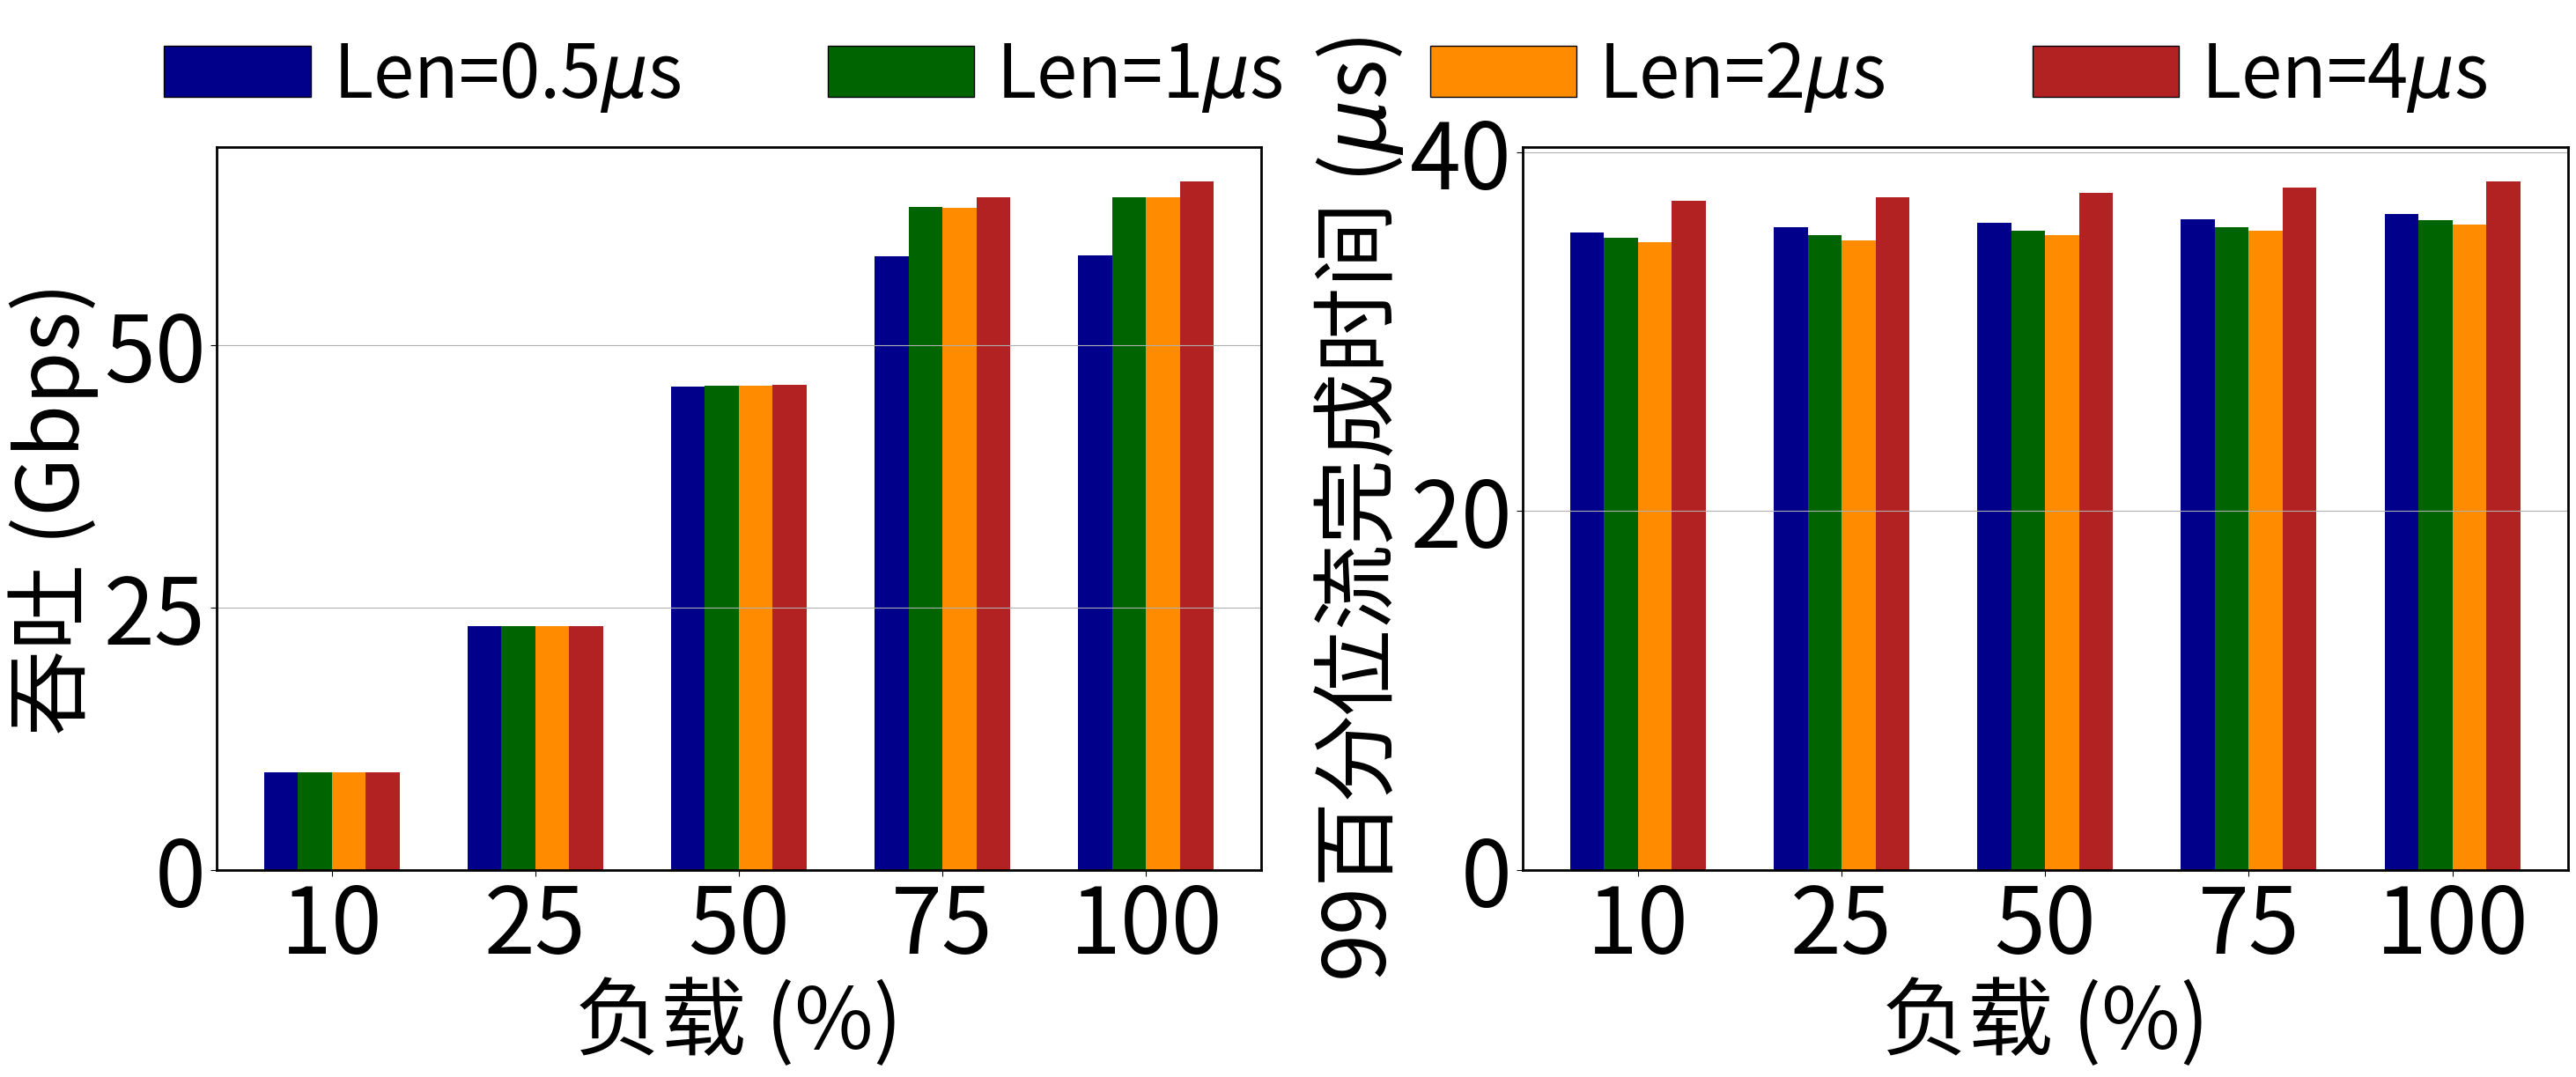

In [27]:
colors = ['white', 'white', 'white', 'white', 'white', 'white', 'white', 'white', 'white', 'white', 'white']
colors = ['darkblue', 'darkgreen', 'darkorange', 'firebrick', 'darkviolet', 'darkred', 'darkblue', 'darkgreen', 'darkorange', 'darkviolet', 'darkred']
# edge_colors = ['firebrick', 'firebrick', 'firebrick', 'firebrick', 'firebrick', 'firebrick', 'firebrick', 'firebrick']
# edge_colors = ['white', 'white', 'white', 'white']
# edge_colors = ['', '', '', '']
hatches = ['o', 'x', '+', '\\', 'x', '...', '-', '|', '\\', '。', '\\']
hatches = ['', '', '', '']
WIDTH = 0.05
my_figsize = [30,12]
my_fontsize = 75
mode = 'multipods'
plt.rc('font', family='Noto Sans CJK JP')

fig_dir = '../FIGS/Thesis/Slot-length/'
if not os.path.exists(fig_dir):
	os.makedirs(fig_dir)
 

# fig, axs = plt.subplots(1, 2, figsize=my_figsize, gridspec_kw={
#         'width_ratios': [1, 1],  # 调整左右子图的宽度比例
#         'wspace': 0.3              # 设置子图之间的水平间距
#     })
fig = plt.figure(figsize=my_figsize, constrained_layout=False)
gs = fig.add_gridspec(
    nrows=2,  # 2行：1行给图例，1行给子图
    ncols=1,
    height_ratios=[0.05, 0.95],  # 图例区域占15%，主图区域占85%
    hspace=0  # 行间距为0
)
sub_gs = gs[1].subgridspec(1, 2, wspace=0.25)
ax1 = fig.add_subplot(sub_gs[0])
ax2 = fig.add_subplot(sub_gs[1])

goodput_bar_plot(labels, ax1)
# plt.savefig(fig_dir + 'goodput.pdf')
slowdown_bar_plot("99p", labels, WORKLOADS[0], ax2, flow_range='Mice', unit='us')

# 创建图例（放在第一行）
handles = [
    plt.Rectangle((0,0), 1, 1, 
        facecolor=colors[i], 
        hatch=hatches[i], 
        edgecolor='black') 
    for i in range(len(SCHEMES_label))
]

# 将图例放在顶部独立区域
leg = fig.legend(
    handles=handles,
    labels=SCHEMES_label,
    loc='upper center',
    ncol=4,  # 水平排列4个图例项
    bbox_to_anchor=(0.52, 1.05),  # 垂直位置调整
    fontsize=my_fontsize-15,
    frameon=False,
    handletextpad=0.3,
    columnspacing=2
)


# fig.subplots_adjust(top=0.90,  # 增加这个值使图上移
#                         bottom=0.2,  # 减少这个值使图上移
#                         left=0.1,
#                         right=0.99,
#                         wspace=0.2)
plt.subplots_adjust(
    top=0.92,  # 给顶部图例留出空间
    bottom=0.2,
    left=0.1,
    right=0.99,
)


plt.savefig(fig_dir + 'fig_with_legend.pdf')
# slowdown_bar_plot("Mean", labels, WORKLOADS[0], flow_range='Elephant', unit='ms')
# plt.savefig(f"../../FIGS/NSDI25-Figures/Multi-Pods/11. Main-Results-FCT.pdf")


In [24]:
# 单独绘制legend
# fig, ax = plt.subplots(figsize=(30, 1))
# ax.axis('off')
# legend_labels = ['RND', 'FCFS', 'LRU', 'SRF']
# # colors = ['firebrick', 'darkblue', 'darkgreen', 'darkorange']
# # hatches = ['o', 'x', '+', '\\']
# for i, label in enumerate(legend_labels):
#     ax.bar(i, 0, color=colors[i], label=label)
# ax.legend(ncol=4, loc='center', fontsize=my_fontsize-5)
# plt.savefig(fig_dir + 'legend.pdf')